# 01 — Data Collection: BTK Inhibitors from ChEMBL

**Target:** Bruton's Tyrosine Kinase (BTK)  
**ChEMBL ID:** CHEMBL5251
**Goal:** Download raw IC50 bioactivity data and save to `data/raw/`

This notebook only collects and inspects data — no cleaning or transformation.

## 1. Imports

In [2]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

# ChEMBL target ID for human BTK
TARGET_ID = 'CHEMBL5251'
OUTPUT_PATH = '../data/raw/btk_raw.csv'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Query ChEMBL for BTK Bioactivity Data

We request all IC50 measurements against human BTK.  
The client handles pagination automatically — we just convert to a list.

In [3]:
activity = new_client.activity

print(f'Querying ChEMBL for IC50 data on target {TARGET_ID}...')

results = activity.filter(
    target_chembl_id=TARGET_ID,
    standard_type='IC50'
).only(
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'standard_relation',
    'pchembl_value',
    'assay_chembl_id',
    'target_chembl_id',
    'document_chembl_id'
)

df = pd.DataFrame.from_records(results)
print(f'Done. {len(df)} records retrieved.')

Querying ChEMBL for IC50 data on target CHEMBL5251...
Done. 21675 records retrieved.


## 3. Initial Inspection

Before saving anything, we look at what arrived:  
shape, column types, and missing value counts.

In [4]:
print('=== Shape ===')
print(df.shape)

print('\n=== Columns ===')
print(df.columns.tolist())

print('\n=== Data types ===')
print(df.dtypes)

=== Shape ===
(21675, 12)

=== Columns ===
['assay_chembl_id', 'canonical_smiles', 'document_chembl_id', 'molecule_chembl_id', 'pchembl_value', 'relation', 'standard_relation', 'standard_units', 'standard_value', 'target_chembl_id', 'units', 'value']

=== Data types ===
assay_chembl_id       str
canonical_smiles      str
document_chembl_id    str
molecule_chembl_id    str
pchembl_value         str
relation              str
standard_relation     str
standard_units        str
standard_value        str
target_chembl_id      str
units                 str
value                 str
dtype: object


In [5]:
print('=== Missing values per column ===')
print(df.isnull().sum())

=== Missing values per column ===
assay_chembl_id          0
canonical_smiles        11
document_chembl_id       0
molecule_chembl_id       0
pchembl_value         5082
relation               122
standard_relation      122
standard_units         122
standard_value         122
target_chembl_id         0
units                  155
value                  122
dtype: int64


In [6]:
print('=== First 5 rows ===')
df.head()

=== First 5 rows ===


,assay_chembl_id,canonical_smiles,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_units,standard_value,target_chembl_id,units,value
0,CHEMBL648220,CCN(CC)C/C=C/c1nc(O)c2c(ccc3nc(Nc4c(Cl)cccc4Cl...,CHEMBL1136753,CHEMBL281957,9.40,=,=,nM,0.4,CHEMBL5251,uM,0.0004
1,CHEMBL648220,CCN(CC)C/C=C/c1nc(O)c2c(ccc3nc(Nc4c(Cl)cccc4Cl...,CHEMBL1136753,CHEMBL281957,9.40,=,=,nM,0.4,CHEMBL5251,uM,0.0004
2,CHEMBL861964,NC(=O)c1sc(-c2ccccc2)cc1N,CHEMBL1147674,CHEMBL207028,4.82,=,=,nM,15100.0,CHEMBL5251,uM,15.1
3,CHEMBL861964,Cc1cc(C)c2c(N)c(C(N)=O)sc2n1,CHEMBL1147674,CHEMBL377085,5.39,=,=,nM,4100.0,CHEMBL5251,uM,4.1
4,CHEMBL865400,COc1cc(C)c(Sc2cnc(NC(=O)c3ccc(CNC(C)C(C)(C)C)c...,CHEMBL1138957,CHEMBL209148,5.39,=,=,nM,4100.0,CHEMBL5251,uM,4.1


In [7]:
# What units are present?
print('=== standard_units value counts ===')
print(df['standard_units'].value_counts())

print('\n=== standard_relation value counts ===')
# Relations like '=', '<', '>' tell us if the IC50 is exact or a bound
print(df['standard_relation'].value_counts())

=== standard_units value counts ===
standard_units
nM    21553
Name: count, dtype: int64

=== standard_relation value counts ===
standard_relation
=     16607
<      3910
>      1018
<=       15
>=        3
Name: count, dtype: int64


In [8]:
# How many unique molecules and assays?
print(f"Unique molecules:  {df['molecule_chembl_id'].nunique()}")
print(f"Unique assays:     {df['assay_chembl_id'].nunique()}")
print(f"Rows with SMILES:  {df['canonical_smiles'].notna().sum()}")
print(f"Rows with IC50:    {df['standard_value'].notna().sum()}")

Unique molecules:  11966
Unique assays:     750
Rows with SMILES:  21664
Rows with IC50:    21553


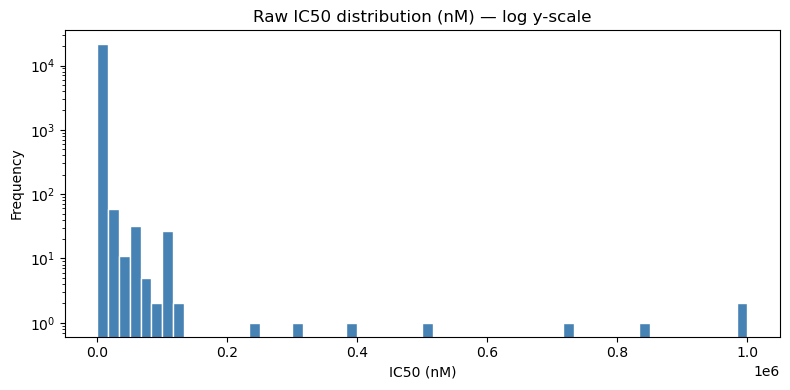

Plot saved to results/


In [9]:
import matplotlib.pyplot as plt

# Quick look at IC50 distribution (raw values, nM)
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')

df['standard_value'].dropna().plot(
    kind='hist',
    bins=60,
    log=True,          # log scale on y-axis: distribution is very skewed
    figsize=(8, 4),
    title='Raw IC50 distribution (nM) — log y-scale',
    xlabel='IC50 (nM)',
    color='steelblue',
    edgecolor='white'
)
plt.tight_layout()
plt.savefig('../results/01_ic50_raw_distribution.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 4. Save Raw Data

We save exactly what arrived from ChEMBL — no modifications.  
This file is the source of truth for all downstream steps.

In [10]:
df.to_csv(OUTPUT_PATH, index=False)
print(f'Raw data saved to {OUTPUT_PATH}')
print(f'Shape: {df.shape}')

Raw data saved to ../data/raw/btk_raw.csv
Shape: (21675, 12)


## Observations from Initial Inspection

### Data volume
- **21.675 records** retrieved from ChEMBL for BTK (CHEMBL5251), IC50 assays
- **11.966 unique molecules** — some compounds were tested in multiple assays
- **750 unique assays** — data comes from a wide range of experimental settings

### Data quality flags (to be addressed in notebook 02)
| Issue | Count | Action |
|-------|-------|--------|
| Non-exact relations (`>`, `<`, `<=`, `>=`) | 4.946 | Discard — these are bounds, not measured values |
| Missing `standard_value` | 122 | Discard |
| Missing `canonical_smiles` | 11 | Discard |
| Non-nM units | 122 | Discard |
| Duplicate molecules (multi-assay) | ~2.500 est. | Aggregate by median pIC50 |

### IC50 distribution
- Highly right-skewed: most compounds cluster at low IC50 values (high potency)
- Expected for BTK, a well-validated kinase target with many potent inhibitors
  developed across multiple drug discovery campaigns
- A few outliers at very high IC50 values will be handled naturally by the
  pIC50 conversion and activity threshold in notebook 02

### Expected yield after curation
Starting from 21.675 records, we expect approximately **8.000–10.000 unique
curated compounds** — a comfortable dataset size for Random Forest and SVM
modeling, and roughly 2x larger than the initial (incorrect) mTOR dataset.

### Note: target correction
This notebook originally used `TARGET_ID = 'CHEMBL2842'` (mTOR) in error.
The correct ChEMBL ID for human BTK is **CHEMBL5251**, confirmed by
the presence of ibrutinib (CHEMBL1873475) with IC50 ~0.3–0.5 nM in the
retrieved dataset, consistent with its known potency against BTK.

## Summary

| Item | Value |
|------|-------|
| Target | BTK (CHEMBL2842) |
| Activity type | IC50 |
| Total records | *(see output above)* |
| Unique molecules | *(see output above)* |
| Output file | `data/raw/btk_raw.csv` |

**Next:** `02_preprocessing.ipynb` — curation, IC50 → pIC50 conversion, activity labeling.